In [ ]:

!pip install streamlit shap scikit-learn xgboost matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 46.9 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import shap
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import streamlit.components.v1 as components
# Load model & features
calibrated_model=joblib.load("best_model.pkl")
feature_names=joblib.load("feature_names.pkl")
st.title("Breast Cancer Prediction Dashboard")
st.sidebar.header("Input Features")
user_input={}
for feature in feature_names:
    user_input[feature]=st.sidebar.number_input(feature, value=0.0)
input_df=pd.DataFrame([user_input])
if st.sidebar.button("Predict"):
    # Prediction
    risk_prob=calibrated_model.predict_proba(input_df)[:, 1][0]
    risk_score=round(risk_prob * 100, 2)
    st.subheader("Prediction")
    prediction="Malignant" if risk_prob>0.5 else"Benign"
    st.write(f"Predicted Class:**{prediction}**")
    st.write(f"Calibrated Risk Score (0–100):**{risk_score}**")
    st.subheader("SHAP Feature Importance (Local Explanation)")
    st.markdown("""
    **What is SHAP?**
    SHAP (SHapley Additive exPlanations) is based on cooperative game theory.
    It assigns each feature a *contribution value* showing how much it pushed the prediction towards **Malignant** or **Benign**.
    - Positive values → push prediction towards **Malignant**
    - Negative values → push prediction towards **Benign**
    """)
    if isinstance(calibrated_model,CalibratedClassifierCV):
        base_model=calibrated_model.estimator
    else:
        base_model=calibrated_model
    def predict_calibrated(x):
        return calibrated_model.predict_proba(x)
    background=shap.sample(pd.DataFrame([user_input]),1,random_state=0)
    explainer=shap.KernelExplainer(predict_calibrated,background)
    shap_values=explainer.shap_values(input_df)
    if isinstance(shap_values, list):
        values=shap_values[1][0]
        base_value=explainer.expected_value[1]
    elif len(shap_values.shape)==3:
        values=shap_values[0, :,1]
        base_value=explainer.expected_value[1]
    else:
        values=shap_values[0]
        base_value=explainer.expected_value

    explanation=shap.Explanation(
        values=values,
        base_values=base_value,
        data=input_df.iloc[0].values,
        feature_names=feature_names
    )

    fig, ax=plt.subplots()
    shap.plots.waterfall(explanation,show=False)
    st.pyplot(fig, bbox_inches="tight")


Writing app.py


In [ ]:

%%writefile requirements.txt
streamlit
scikit-learn
xgboost
shap
matplotlib
seaborn
pandas
numpy
joblib


Writing requirements.txt


Saving data (1).csv to data (1).csv
Shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42        

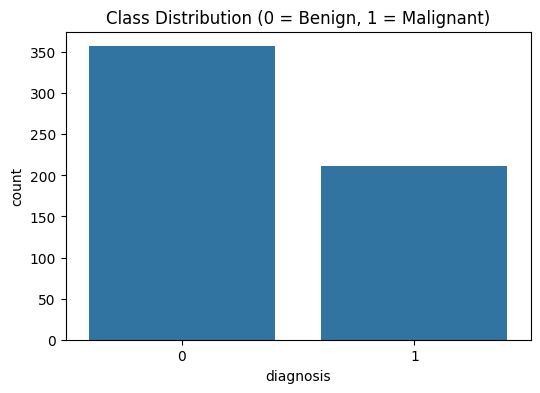

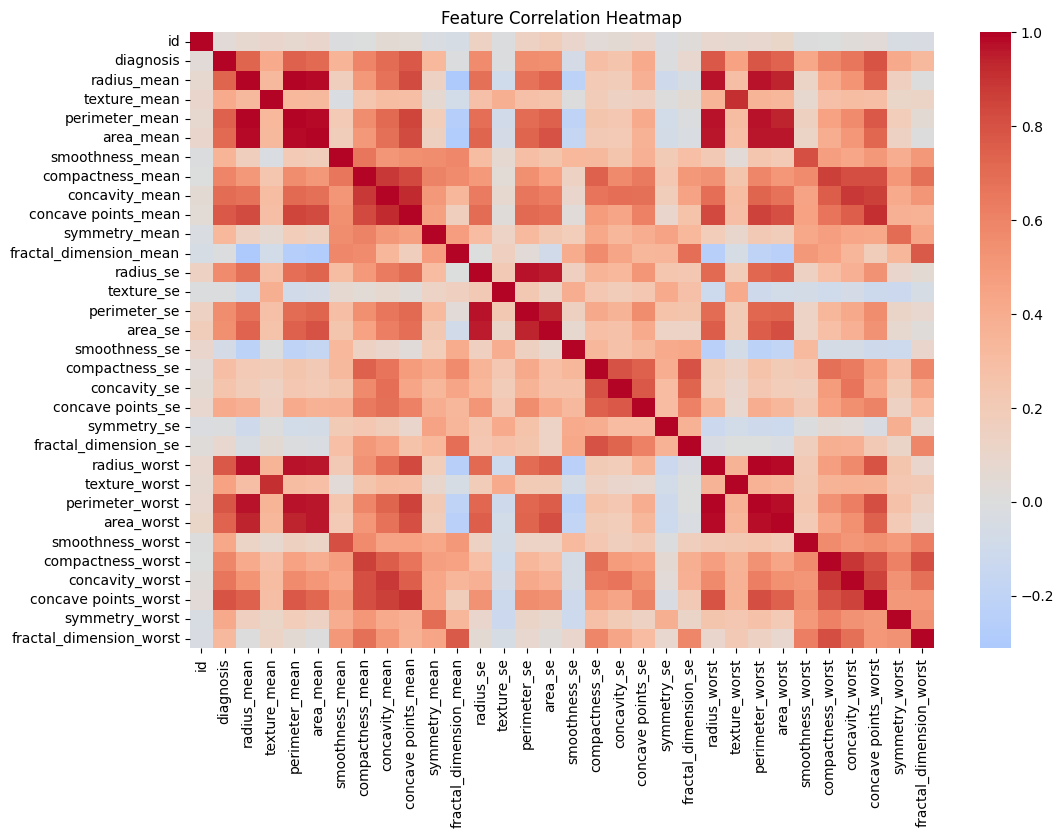

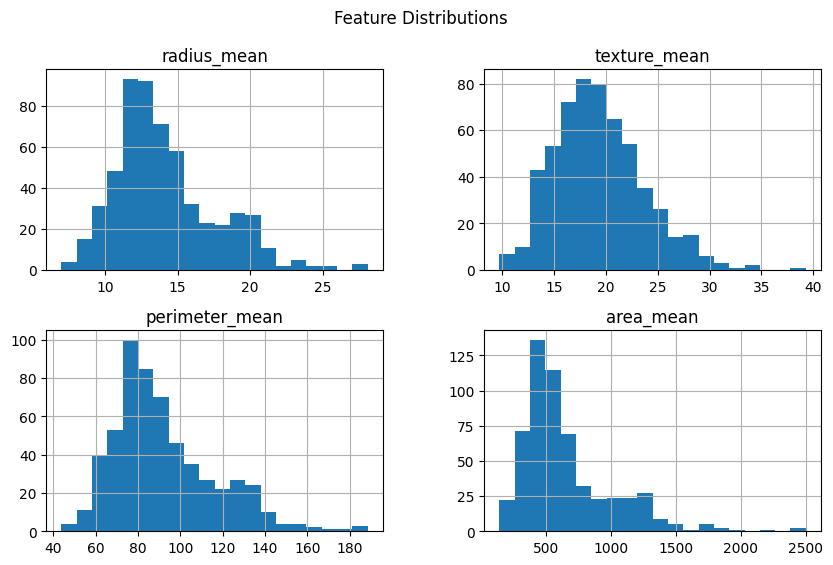

Train shape: (455, 31)
Test shape: (114, 31)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_5921/1441366084.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy",y="Model",data=results_df,palette="viridis")



Model Accuracies:
Logistic Regression: 0.9123
Decision Tree: 0.9211
Random Forest: 0.9737
SVM: 0.6316
KNN: 0.7544
XGBoost: 0.9737

Comparison Table:
                 Model  Accuracy
0  Logistic Regression  0.912281
1        Decision Tree  0.921053
2        Random Forest  0.973684
3                  SVM  0.631579
4                  KNN  0.754386
5              XGBoost  0.973684


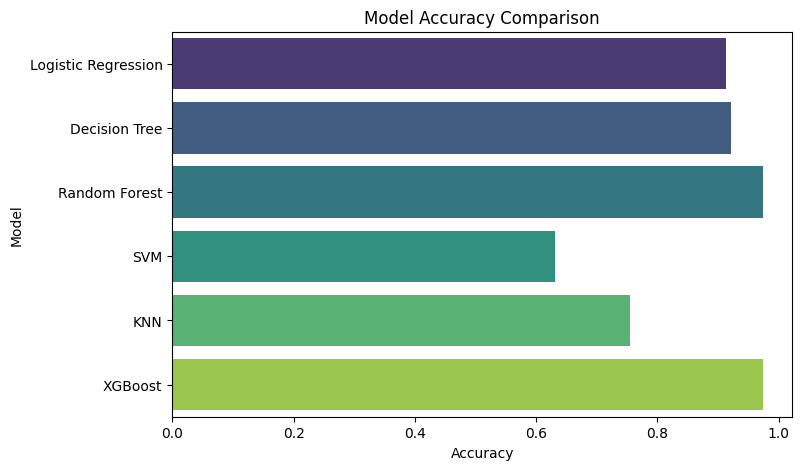


Best Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


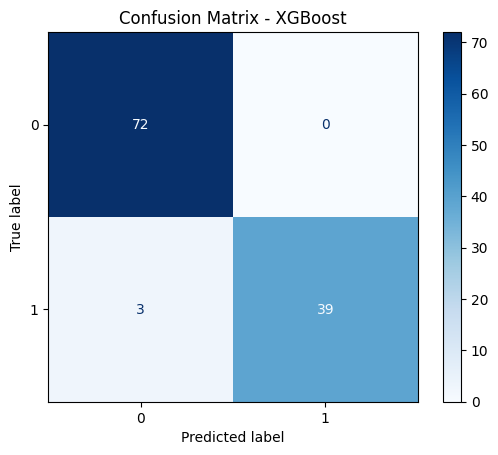

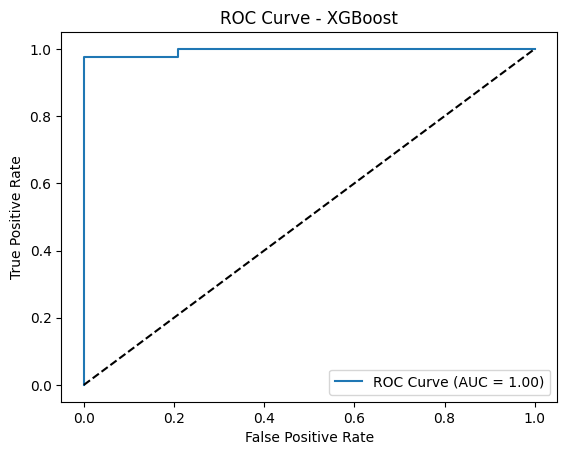

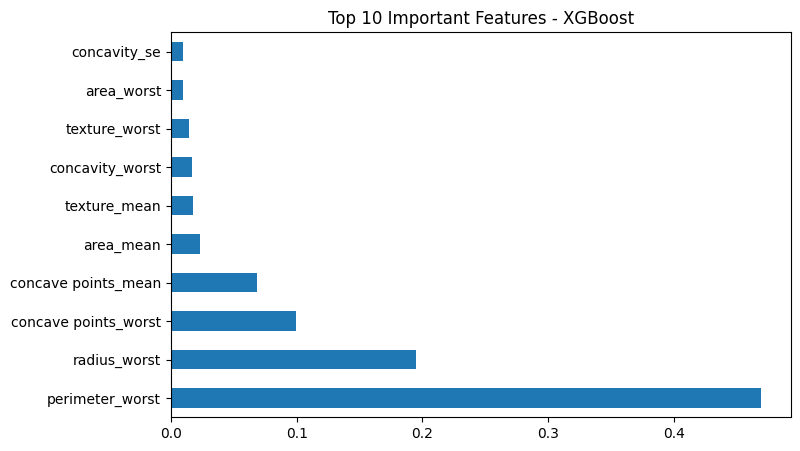

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Sample Calibrated Risk Scores (0–100):
[  0.95 100.    13.15 100.     5.64   0.95  91.94   0.95   0.15   0.95]


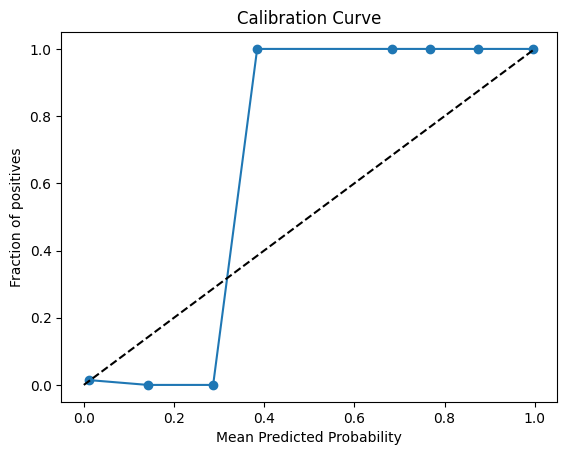

Selected test sample index: 0
Using TreeExplainer on base (uncalibrated) model
Plotting SHAP summary (global importance)...
Could not create SHAP summary plot: Summary plots need a matrix of shap_values, not a vector.

Local SHAP for selected sample (waterfall):


Local SHAP failed: object of type 'numpy.float32' has no len()

Calibrated risk for sample index 0: 0.95 %
Predicted class (threshold 0.5): Benign
Files download failed (only works in Colab).


In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from google.colab import files
uploaded=files.upload()
filename=list(uploaded.keys())[0]
df=pd.read_csv(filename)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
df["diagnosis"]=df["diagnosis"].map({"M": 1, "B": 0})
print("\nClass distribution:")
print(df["diagnosis"].value_counts())

#EDA
plt.figure(figsize=(6,4))
sns.countplot(x="diagnosis", data=df)
plt.title("Class Distribution (0 = Benign, 1 = Malignant)")
plt.show()
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()
features=["radius_mean", "texture_mean", "perimeter_mean", "area_mean"]
df[features].hist(bins=20, figsize=(10, 6))
plt.suptitle("Feature Distributions")
plt.show()

#Data spliting
X=df.drop("diagnosis", axis=1)
y=df["diagnosis"]
X_train,X_test,y_train,y_test=train_test_split(
    X, y,test_size=0.2,random_state=42,stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

#Differents types of model traning
models={
    "Logistic Regression":LogisticRegression(max_iter=5000),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "SVM":SVC(probability=True),
    "KNN":KNeighborsClassifier(),
    "XGBoost":XGBClassifier(eval_metric='logloss', use_label_encoder=False)
}
results={}
for name,model in models.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    results[name]=accuracy_score(y_test, y_pred)
print("\nModel Accuracies:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")
results_df=pd.DataFrame(list(results.items()),columns=["Model", "Accuracy"])
print("\nComparison Table:")
print(results_df)
plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy",y="Model",data=results_df,palette="viridis")
plt.title("Model Accuracy Comparison")
plt.show()

# Best model evaluation
best_model_name=results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
print(f"\nBest Model: {best_model_name}")
best_model=models[best_model_name]
best_model.fit(X_train, y_train)
y_pred=best_model.predict(X_test)
cm=confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()
y_prob=best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _=roc_curve(y_test, y_prob)
roc_auc=auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()
if hasattr(best_model, "feature_importances_"):
    importances=best_model.feature_importances_
    feat_names=X.columns
    feat_imp=pd.Series(importances, index=feat_names).sort_values(ascending=False)[:10]
    plt.figure(figsize=(8,5))
    feat_imp.plot(kind='barh')
    plt.title(f"Top 10 Important Features - {best_model_name}")
    plt.show()

#Risk score calibaration(0-100)
calibrated_model=CalibratedClassifierCV(best_model,method="isotonic",cv=5)
calibrated_model.fit(X_train, y_train)
y_prob_calibrated=calibrated_model.predict_proba(X_test)[:, 1]
risk_scores=(y_prob_calibrated * 100).round(2)
print("\nSample Calibrated Risk Scores (0–100):")
print(risk_scores[:10])
prob_true, prob_pred=calibration_curve(y_test, y_prob_calibrated, n_bins=10)
plt.plot(prob_pred,prob_true,marker='o')
plt.plot([0,1],[0,1],"k--")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.show()

#SHAP Explanation
X_test_reset=X_test.reset_index(drop=True)
sample_index=0
sample=X_test_reset.iloc[sample_index:sample_index+1]
print(f"Selected test sample index: {sample_index}")
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
base_model_for_shap=best_model
is_tree_model=isinstance(base_model_for_shap, (RandomForestClassifier,DecisionTreeClassifier,XGBClassifier))
if is_tree_model:
    print("Using TreeExplainer on base (uncalibrated) model")
    explainer=shap.TreeExplainer(base_model_for_shap)
    shap_values=explainer.shap_values(X_test_reset)
else:
    print("Using KernelExplainer on calibrated model")
    def predict_prob_class1(x):
        return calibrated_model.predict_proba(pd.DataFrame(x,columns=X_train.columns))[:, 1]
    background=shap.sample(X_train,min(100,len(X_train)),random_state=0)
    explainer=shap.KernelExplainer(predict_prob_class1,background)
    subset=X_test_reset.sample(n=min(50, len(X_test_reset)),random_state=0)
    shap_values=explainer.shap_values(subset,nsamples=100)

# Global SHAP summary
try:
    print("Plotting SHAP summary (global importance)...")
    if is_tree_model:
        class1_shap=shap_values[1]
        target_data=X_test_reset
    else:
        class1_shap=shap_values
        target_data=subset
    shap.summary_plot(class1_shap,target_data,show=True)
except Exception as e:
    print("Could not create SHAP summary plot:", e)

# Local SHAP for selected sample
try:
    print("\nLocal SHAP for selected sample (waterfall):")
    shap.initjs()
    if is_tree_model:
        single_shap=shap_values[1][sample_index]
        expected_value=explainer.expected_value[1] if isinstance(explainer.expected_value,(list,tuple)) else explainer.expected_value
    else:
        single_shap=shap_values[0]
        expected_value=explainer.expected_value
    shap.plots._waterfall.waterfall_legacy(expected_value,single_shap,feature_names=sample.columns)
except Exception as e:
    print("Local SHAP failed:",e)
sample_prob=calibrated_model.predict_proba(sample)[:, 1][0]
sample_risk=round(float(sample_prob) * 100,2)
print(f"\nCalibrated risk for sample index {sample_index}: {sample_risk} %")
print(f"Predicted class (threshold 0.5): {'Malignant' if sample_prob>=0.5 else 'Benign'}")

#Models and Features saving
joblib.dump(calibrated_model,"best_model.pkl")
joblib.dump(X_train.columns.tolist(),"feature_names.pkl")

#DASHBOARD
# Saving of requirements.txt
# with open("requirements.txt","w") as f:
#     f.write("pandas\nnumpy\nmatplotlib\nseaborn\njoblib\nshap\nscikit-learn\nxgboost\n")

# # Files downloading for Dashboard
# try:
#     files.download("app.py")
#     files.download("best_model.pkl")
#     files.download("feature_names.pkl")
#     files.download("requirements.txt")
# except Exception as e:
#     print("Files download failed (only works in Colab).")

